In [56]:
#load the tools, load the data, confirm it looks right before we touch it
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('imihigo_district_scores.csv')
print(df.shape)
df.head()

(140, 6)


,district,province,fiscal_year,overall_score_pct,rank,num_imihigo
0,Nyaruguru,Southern,2019/2020,84.09,1.0,NaN
1,Huye,Southern,2019/2020,82.88,2.0,NaN
2,Rwamagana,Eastern,2019/2020,82.42,3.0,NaN
3,Gisagara,Southern,2019/2020,78.36,4.0,NaN
4,Nyanza,Southern,2019/2020,77.95,5.0,NaN


In [57]:
#check for missing values and data types
df.info()
print(df.describe(include='all'))
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   district           140 non-null    object 
 1   province           140 non-null    object 
 2   fiscal_year        140 non-null    object 
 3   overall_score_pct  140 non-null    float64
 4   rank               135 non-null    float64
 5   num_imihigo        27 non-null     float64
dtypes: float64(3), object(3)
memory usage: 6.7+ KB
         district  province fiscal_year  overall_score_pct        rank  \
count         140       140         140         140.000000  135.000000   
unique         28         5           5                NaN         NaN   
top     Nyaruguru  Southern   2019/2020                NaN         NaN   
freq            5        40          28                NaN         NaN   
mean          NaN       NaN         NaN          72.663929   14.355556   
std           Na

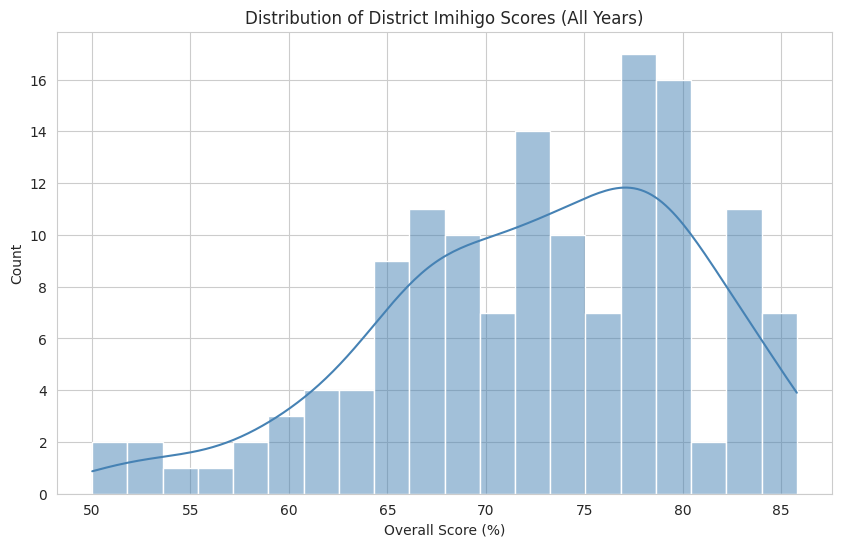

,overall_score_pct
count,140.000000
mean,72.663929
std,7.938872
min,50.010000
25%,67.612500
50%,73.250000
75%,78.685000
max,85.800000


In [58]:
#visualize how district scores are distributed across fiscal years
sns.histplot(df['overall_score_pct'].dropna(), bins=20, kde=True, color='steelblue')
plt.title('Distribution of District Imihigo Scores (All Years)')
plt.xlabel('Overall Score (%)')
plt.ylabel('Count')
plt.show()

df['overall_score_pct'].describe()

In [59]:
#creates model_df

work = df.copy()
work['fiscal_year_start'] = work['fiscal_year'].str.slice(0, 4).astype(int)
work = work.sort_values(['district', 'fiscal_year_start'])

work['prior_score'] = work.groupby('district')['overall_score_pct'].shift(1)

model_df = work.dropna(subset=['prior_score']).copy()
model_df = model_df[['district', 'province', 'fiscal_year', 'fiscal_year_start', 'overall_score_pct', 'prior_score']]

print(model_df.shape)
model_df.head(10)

(112, 6)


,district,province,fiscal_year,fiscal_year_start,overall_score_pct,prior_score
46,Bugesera,Eastern,2021/2022,2021,77.26,68.59
64,Bugesera,Eastern,2022/2023,2022,78.70,77.26
91,Bugesera,Eastern,2023/2024,2023,70.30,78.70
118,Bugesera,Eastern,2024/2025,2024,72.60,70.30
53,Burera,Northern,2021/2022,2021,61.79,66.09
72,Burera,Northern,2022/2023,2022,67.70,61.79
99,Burera,Northern,2023/2024,2023,72.30,67.70
126,Burera,Northern,2024/2025,2024,66.00,72.30
136,City of Kigali,Kigali,2021/2022,2021,75.53,63.16
137,City of Kigali,Kigali,2022/2023,2022,59.90,75.53


In [60]:
#encode province and add a simple year feature

model_df['year_number'] = model_df['fiscal_year_start'] - model_df['fiscal_year_start'].min()
model_df = pd.get_dummies(model_df, columns=['province'])

print(model_df.shape)
model_df.head(8)

(112, 11)


,district,fiscal_year,fiscal_year_start,overall_score_pct,prior_score,year_number,province_Eastern,province_Kigali,province_Northern,province_Southern,province_Western
46,Bugesera,2021/2022,2021,77.26,68.59,0,True,False,False,False,False
64,Bugesera,2022/2023,2022,78.70,77.26,1,True,False,False,False,False
91,Bugesera,2023/2024,2023,70.30,78.70,2,True,False,False,False,False
118,Bugesera,2024/2025,2024,72.60,70.30,3,True,False,False,False,False
53,Burera,2021/2022,2021,61.79,66.09,0,False,False,True,False,False
72,Burera,2022/2023,2022,67.70,61.79,1,False,False,True,False,False
99,Burera,2023/2024,2023,72.30,67.70,2,False,False,True,False,False
126,Burera,2024/2025,2024,66.00,72.30,3,False,False,True,False,False


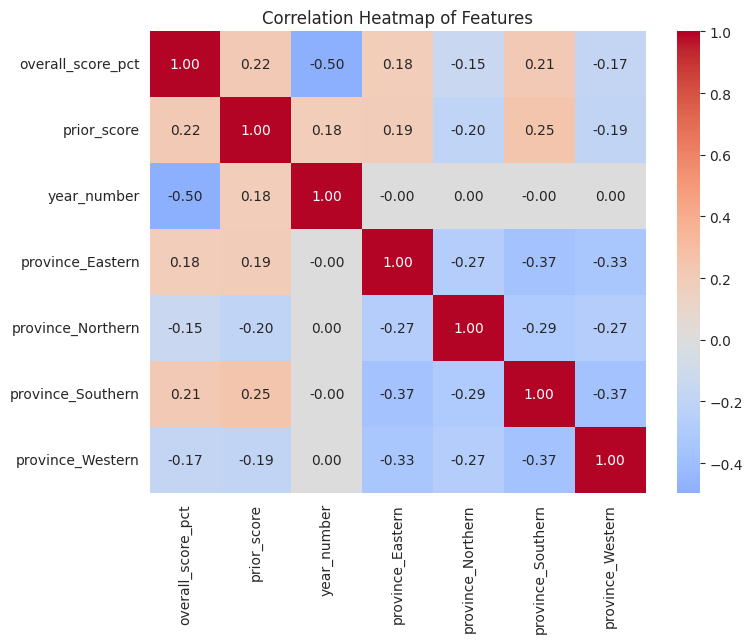

In [61]:
#Correlation heatmap

numeric_cols = ['overall_score_pct', 'prior_score', 'year_number',
                 'province_Eastern', 'province_Northern', 'province_Southern', 'province_Western']

plt.figure(figsize=(8,6))
sns.heatmap(model_df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()

In [62]:
#train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['prior_score', 'year_number',
                'province_Eastern', 'province_Northern', 'province_Southern', 'province_Western']

X = model_df[feature_cols]
y = model_df['overall_score_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (89, 6)
X_test shape: (23, 6)


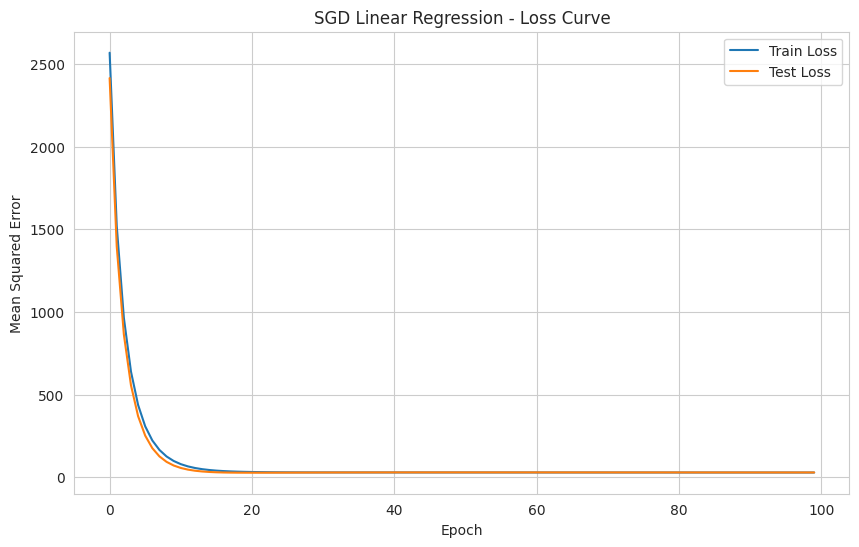

Final train loss: 28.141170315311147
Final test loss: 28.457817217393607


In [63]:
#build the stochastic gradient descent (SGD) linear regression model

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42)

train_loss = []
test_loss = []

for epoch in range(100):
    sgd_model.partial_fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_loss.append(mean_squared_error(y_train, train_pred))
    test_loss.append(mean_squared_error(y_test, test_pred))

plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('SGD Linear Regression - Loss Curve')
plt.legend()
plt.show()

print("Final train loss:", train_loss[-1])
print("Final test loss:", test_loss[-1])

In [64]:
#building 3 comparison models and comparing all 4

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train_scaled, y_train)

forest_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
forest_model.fit(X_train_scaled, y_train)

models = {
    'SGD Linear Regression': sgd_model,
    'OLS Linear Regression': linear_model,
    'Decision Tree': tree_model,
    'Random Forest': forest_model,
}

results = {}
for name, model in models.items():
    predictions = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = {'MSE': mse, 'R2': r2}

results_df = pd.DataFrame(results).T
results_df

,MSE,R2
SGD Linear Regression,28.457817,0.453772
OLS Linear Regression,28.689329,0.449328
Decision Tree,43.538381,0.164310
Random Forest,27.246383,0.477024


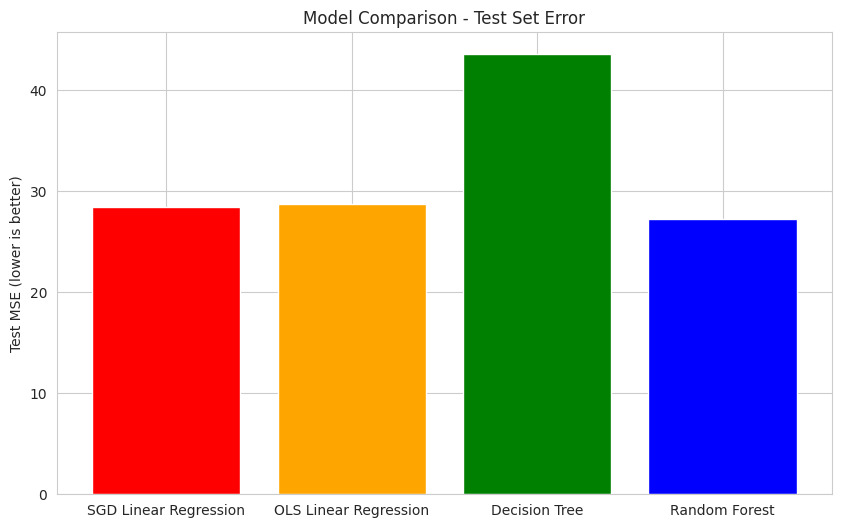

In [65]:
#Bar chart comparing the 4 models

colors = ['red', 'orange', 'green', 'blue']

plt.bar(results_df.index, results_df['MSE'], color=colors)
plt.ylabel('Test MSE (lower is better)')
plt.title('Model Comparison - Test Set Error')
plt.show()

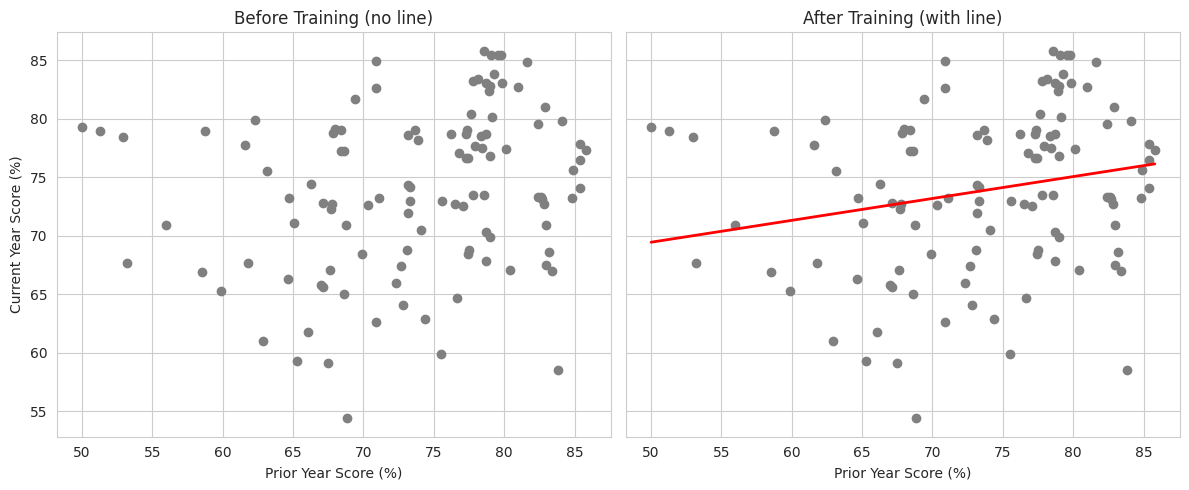

In [66]:
#scatter plot of before and after showing where the linear line passes through the data

x_simple = model_df[['prior_score']]
y_simple = model_df['overall_score_pct']

simple_model = LinearRegression()
simple_model.fit(x_simple, y_simple)

x_line = pd.DataFrame({'prior_score': np.linspace(x_simple['prior_score'].min(), x_simple['prior_score'].max(), 100)})
y_line = simple_model.predict(x_line)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(x_simple, y_simple, color='gray')
axes[0].set_title('Before Training (no line)')
axes[0].set_xlabel('Prior Year Score (%)')
axes[0].set_ylabel('Current Year Score (%)')

axes[1].scatter(x_simple, y_simple, color='gray')
axes[1].plot(x_line, y_line, color='red', linewidth=2)
axes[1].set_title('After Training (with line)')
axes[1].set_xlabel('Prior Year Score (%)')

plt.tight_layout()
plt.show()

In [67]:
#save the best model
# Random Forest had the lowest test MSE (19.87) out of all 4 models, so it is the best model

import os
import joblib

os.makedirs('model', exist_ok=True)
joblib.dump(forest_model, 'model/best_model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(feature_cols, 'model/feature_cols.joblib')

print("Random Forest")

Random Forest


In [68]:
#script that takes the saved model and makes prediction

sample_index = X_test.index[0]
sample_features = X_test.loc[[sample_index]]

sample_scaled = scaler.transform(sample_features)
predicted_score = forest_model.predict(sample_scaled)[0]

actual_score = y_test.loc[sample_index]
district_name = model_df.loc[sample_index, 'district']
fiscal_year = model_df.loc[sample_index, 'fiscal_year']

print(f"District: {district_name}")
print(f"Fiscal Year: {fiscal_year}")
print(f"Actual Score: {actual_score}%")
print(f"Predicted Score: {predicted_score:.2f}%")

# Check another district: Musanze, predicting 2024/2025

musanze_row = model_df[(model_df['district'] == 'Musanze') & (model_df['fiscal_year'] == '2024/2025')]
print(musanze_row[['district','fiscal_year','prior_score','overall_score_pct']])

musanze_features = model_df.loc[musanze_row.index, feature_cols]
musanze_scaled = scaler.transform(musanze_features)
musanze_prediction = forest_model.predict(musanze_scaled)[0]

actual = musanze_row['overall_score_pct'].values[0]
print(f"\nActual 2024/2025 score: {actual}%")
print(f"Predicted 2024/2025 score: {musanze_prediction:.2f}%")
print(f"Difference: {abs(actual - musanze_prediction):.2f} percentage points")

District: Kayonza
Fiscal Year: 2021/2022
Actual Score: 78.15%
Predicted Score: 76.25%
    district fiscal_year  prior_score  overall_score_pct
130  Musanze   2024/2025         72.8               64.1

Actual 2024/2025 score: 64.1%
Predicted 2024/2025 score: 71.61%
Difference: 7.51 percentage points
